<a href="https://colab.research.google.com/github/P-Karthikeya512/Modifications_in_skip_connections_of_UNET_and_similar_arch/blob/main/Multi_Skip_UNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

prabhalakarthikeya_isic2018_task1_path = kagglehub.dataset_download('prabhalakarthikeya/isic2018-task1')

print('Data source import complete.')


In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

In [ ]:
import os
import glob
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split
dataset_path = "/kaggle/input/datasets/prabhalakarthikeya/isic2018-task1/Unet_implementation"

print(os.listdir(dataset_path))
TRAIN_IMAGES = dataset_path + "/images/train"
TRAIN_MASKS  = dataset_path + "/masks/train"

VAL_IMAGES   = dataset_path + "/images/val"
VAL_MASKS    = dataset_path + "/masks/val"

TEST_IMAGES  = dataset_path + "/images/test"
TEST_MASKS   = dataset_path + "/masks/test"

print("Train Images :", len(os.listdir(TRAIN_IMAGES)))
print("Train Masks  :", len(os.listdir(TRAIN_MASKS)))

print("Val Images   :", len(os.listdir(VAL_IMAGES)))
print("Val Masks    :", len(os.listdir(VAL_MASKS)))

print("Test Images  :", len(os.listdir(TEST_IMAGES)))
print("Test Masks   :", len(os.listdir(TEST_MASKS)))

IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32
EPOCHS = 50
AUTOTUNE = tf.data.AUTOTUNE

['images', 'masks']
Train Images : 2596
Train Masks  : 2596
Val Images   : 102
Val Masks    : 102
Test Images  : 1002
Test Masks   : 1002


['ISIC_0000000.jpg', 'ISIC_0000001.jpg', 'ISIC_0000003.jpg', 'ISIC_0000004.jpg', 'ISIC_0000006.jpg']
['ISIC_0000000_segmentation.png', 'ISIC_0000001_segmentation.png', 'ISIC_0000003_segmentation.png', 'ISIC_0000004_segmentation.png', 'ISIC_0000006_segmentation.png']


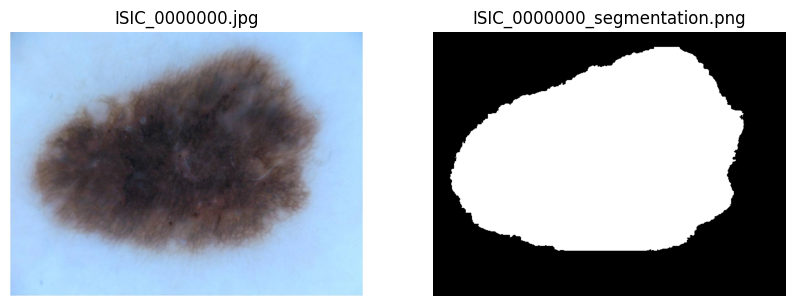

In [ ]:
image_files = sorted([
    f for f in os.listdir(TRAIN_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

mask_files = sorted([
    f for f in os.listdir(TRAIN_MASKS)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(image_files[:5])
print(mask_files[:5])

img_name = image_files[0]
mask_name = mask_files[0]

image = cv2.cvtColor(
    cv2.imread(os.path.join(TRAIN_IMAGES, img_name)),
    cv2.COLOR_BGR2RGB
)

mask = cv2.imread(
    os.path.join(TRAIN_MASKS, mask_name),
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title(img_name)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title(mask_name)
plt.axis("off")

plt.show()

In [ ]:
def create_pairs(image_dir, mask_dir):
    image_paths = sorted(
        glob.glob(os.path.join(image_dir, "*.jpg")) +
        glob.glob(os.path.join(image_dir, "*.jpeg")) +
        glob.glob(os.path.join(image_dir, "*.png"))
    )

    pairs = []
    for img_path in image_paths:
        image_name = os.path.basename(img_path)
        stem, _ = os.path.splitext(image_name)

        # ISIC 2018 masks usually follow: <image_id>_segmentation.png
        mask_path_png = os.path.join(mask_dir, stem + "_segmentation.png")
        mask_path_jpg = os.path.join(mask_dir, stem + "_segmentation.jpg")
        mask_path_jpeg = os.path.join(mask_dir, stem + "_segmentation.jpeg")

        if os.path.exists(mask_path_png):
            pairs.append((img_path, mask_path_png))
        elif os.path.exists(mask_path_jpg):
            pairs.append((img_path, mask_path_jpg))
        elif os.path.exists(mask_path_jpeg):
            pairs.append((img_path, mask_path_jpeg))

    return pairs

train_pairs = create_pairs(TRAIN_IMAGES, TRAIN_MASKS)
val_pairs   = create_pairs(VAL_IMAGES, VAL_MASKS)
test_pairs  = create_pairs(TEST_IMAGES, TEST_MASKS)

print("\nPaired samples:")
print("Train pairs:", len(train_pairs))
print("Val pairs  :", len(val_pairs))
print("Test pairs :", len(test_pairs))

print("First train pair:", train_pairs[0] if len(train_pairs) > 0 else "No pairs found")


Paired samples:
Train pairs: 2594
Val pairs  : 100
Test pairs : 1000
First train pair: ('/kaggle/input/datasets/prabhalakarthikeya/isic2018-task1/Unet_implementation/images/train/ISIC_0000000.jpg', '/kaggle/input/datasets/prabhalakarthikeya/isic2018-task1/Unet_implementation/masks/train/ISIC_0000000_segmentation.png')


In [ ]:
# =========================
# Read functions
# =========================
def read_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0
    return image

def read_mask(path):
    mask = tf.io.read_file(path)
    # ISIC masks are commonly PNG; if your masks are JPG, decode_jpeg can be used instead
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMG_HEIGHT, IMG_WIDTH), method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return mask
def load_data(image_path, mask_path):
    image = read_image(image_path)
    mask = read_mask(mask_path)
    return image, mask

# =========================
# Quick sanity check
# =========================
if len(train_pairs) > 0:
    image = read_image(train_pairs[0][0])
    mask = read_mask(train_pairs[0][1])
    print("\nSingle sample shapes:")
    print("Image:", image.shape)
    print("Mask :", mask.shape)

# =========================
# Convert pairs to path lists
# =========================
train_images = [x[0] for x in train_pairs]
train_masks  = [x[1] for x in train_pairs]

val_images = [x[0] for x in val_pairs]
val_masks  = [x[1] for x in val_pairs]

test_images = [x[0] for x in test_pairs]
test_masks  = [x[1] for x in test_pairs]

I0000 00:00:1785144997.105703      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785144997.112730      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Single sample shapes:
Image: (128, 128, 3)
Mask : (128, 128, 1)


In [ ]:
# =========================
# Augmentation
# =========================
def augment(image, mask):
    # Horizontal flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Vertical flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Random 90-degree rotation
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    # Image-only augmentations
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.9, 1.1)
    return image, mask

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.007684469..1.0347295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07008201..1.013351].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04654908..1.0375136].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.022080302..1.0477282].



Batched shapes:
Images: (32, 128, 128, 3)
Masks : (32, 128, 128, 1)


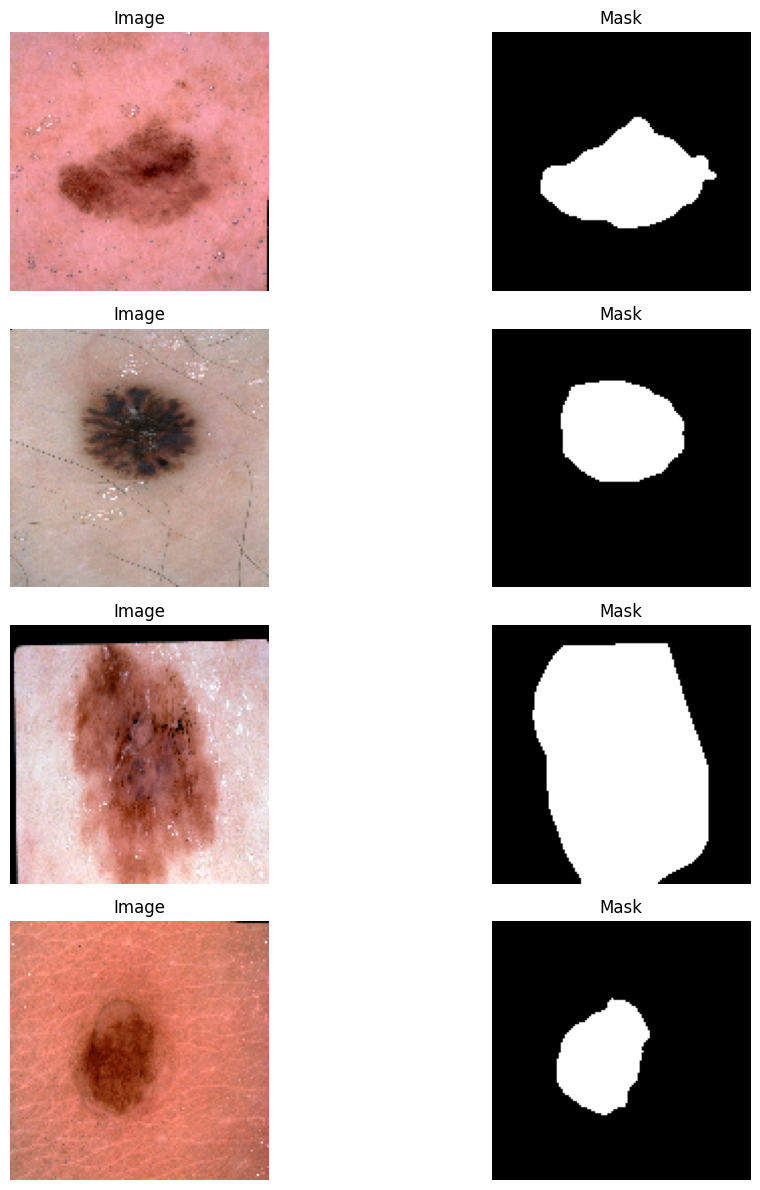


Final dataset sizes:
Train: 2594
Val  : 100
Test : 1000


In [ ]:
def create_dataset(image_paths, mask_paths, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, mask_paths)
    )
    dataset = dataset.map(
        load_data,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    # Cache after loading/resizing
    dataset = dataset.cache()

    if training:
        dataset = dataset.shuffle(len(image_paths))
        dataset = dataset.map(
            augment,
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = create_dataset(train_images, train_masks, training=True)
val_ds   = create_dataset(val_images, val_masks, training=False)
test_ds  = create_dataset(test_images, test_masks, training=False)

# =========================
# Verify dataset pipeline
# =========================
for image, mask in train_ds.take(1):
    print("\nBatched shapes:")
    print("Images:", image.shape)
    print("Masks :", mask.shape)

    plt.figure(figsize=(12, 12))
    for i in range(min(4, image.shape[0])):
        plt.subplot(4, 2, 2 * i + 1)
        plt.imshow(image[i])
        plt.axis("off")
        plt.title("Image")

        plt.subplot(4, 2, 2 * i + 2)
        plt.imshow(tf.squeeze(mask[i]), cmap="gray")
        plt.axis("off")
        plt.title("Mask")

    plt.tight_layout()
    plt.show()

# =========================
# Optional: final dataset stats
# =========================
print("\nFinal dataset sizes:")
print("Train:", len(train_images))
print("Val  :", len(val_images))
print("Test :", len(test_images))

## Metrics and Loss Function

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) +
        tf.reduce_sum(y_pred_f) +
        smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = (
        tf.reduce_sum(y_true_f)
        + tf.reduce_sum(y_pred_f)
        - intersection
    )

    return (intersection + smooth) / (union + smooth)

## Building UNET Blocks

In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def down_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPool2D((2, 2))(c)
    p = layers.Dropout(0.2)(p)
    return c, p

def resize_to_ref(tensor, ref, name=None):
    return layers.Lambda(
        lambda t: tf.image.resize(t[0], tf.shape(t[1])[1:3], method="bilinear"),
        name=name
    )([tensor, ref])


def project_and_resize(skip, ref, filters):
    # reduce channels first
    skip = layers.Conv2D(filters, 1, padding="same", kernel_initializer="he_normal")(skip)
    skip = layers.BatchNormalization()(skip)
    skip = layers.ReLU()(skip)

    # then match spatial size
    skip = resize_to_ref(skip, ref)
    return skip

def up_block(x, skips, filters):
    # upsample decoder feature
    x = layers.UpSampling2D((2, 2), interpolation="bilinear")(x)
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    fused = [x]

    # add multiple skip tensors after aligning shape
    for s in skips:
        if s is not None:
            s = project_and_resize(s, x, filters)
            fused.append(s)

    if len(fused) > 1:
        x = layers.Concatenate()(fused)

    x = layers.Dropout(0.2)(x)
    x = conv_block(x, filters)
    return x

## Build UNET

In [ ]:
def build_unet(input_shape=(128,128,3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1, p1 = down_block(inputs, 32)   # 256 -> 128
    c2, p2 = down_block(p1, 64)       # 128 -> 64
    c3, p3 = down_block(p2, 128)      # 64 -> 32
    c4, p4 = down_block(p3, 256)      # 32 -> 16

    # Bottleneck
    bottleneck = conv_block(p4, 512)

    # Decoder with multi-skip fusion
    # up1 = 16 -> 32
    u1 = up_block(bottleneck, [c4], 256)

    # up2 = 32 -> 64, fuse c3 + c4
    u2 = up_block(u1, [c3, c4], 128)

    # up3 = 64 -> 128, fuse c2 + c3
    u3 = up_block(u2, [c2, c3], 64)

    # up4 = 128 -> 256, fuse c1 + c2
    u4 = up_block(u3, [c1, c2], 32)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(u4)

    model = Model(inputs, outputs, name="UNet_MultiSkip_Resized")
    return model


strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    model = build_unet()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=dice_loss,
        metrics=["accuracy", dice_coef, iou_coef]
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


Model: "UNet_MultiSkip_Resized"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_58 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 128, 128,  │      9,248 │ re_lu_58[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_59 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ re_lu_59[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 64, 64,    │          0 │ max_pooling2d_8[… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 64, 64,    │     18,496 │ dropout_16[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_60 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 64, 64,    │     36,928 │ re_lu_60[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_61 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ re_lu_61[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 32, 32,    │          0 │ max_pooling2d_9[

 Total params: 8,971,297 (34.22 MB)

 Trainable params: 8,963,041 (34.19 MB)

 Non-trainable params: 8,256 (32.25 KB)

## Callbacks and Training

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet.keras",
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

In [ ]:
test_results = model.evaluate(test_ds, verbose=1)

print(f"Test Loss     : {test_results[0]:.4f}")
print(f"Test Accuracy : {test_results[1]:.4f}")
print(f"Test Dice     : {test_results[2]:.4f}")
print(f"Test IoU      : {test_results[3]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 975ms/step - accuracy: 0.9205 - dice_coef: 0.8484 - iou_coef: 0.7466 - loss: 0.3070
Test Loss     : 0.3070
Test Accuracy : 0.9205
Test Dice     : 0.8484
Test IoU      : 0.7466


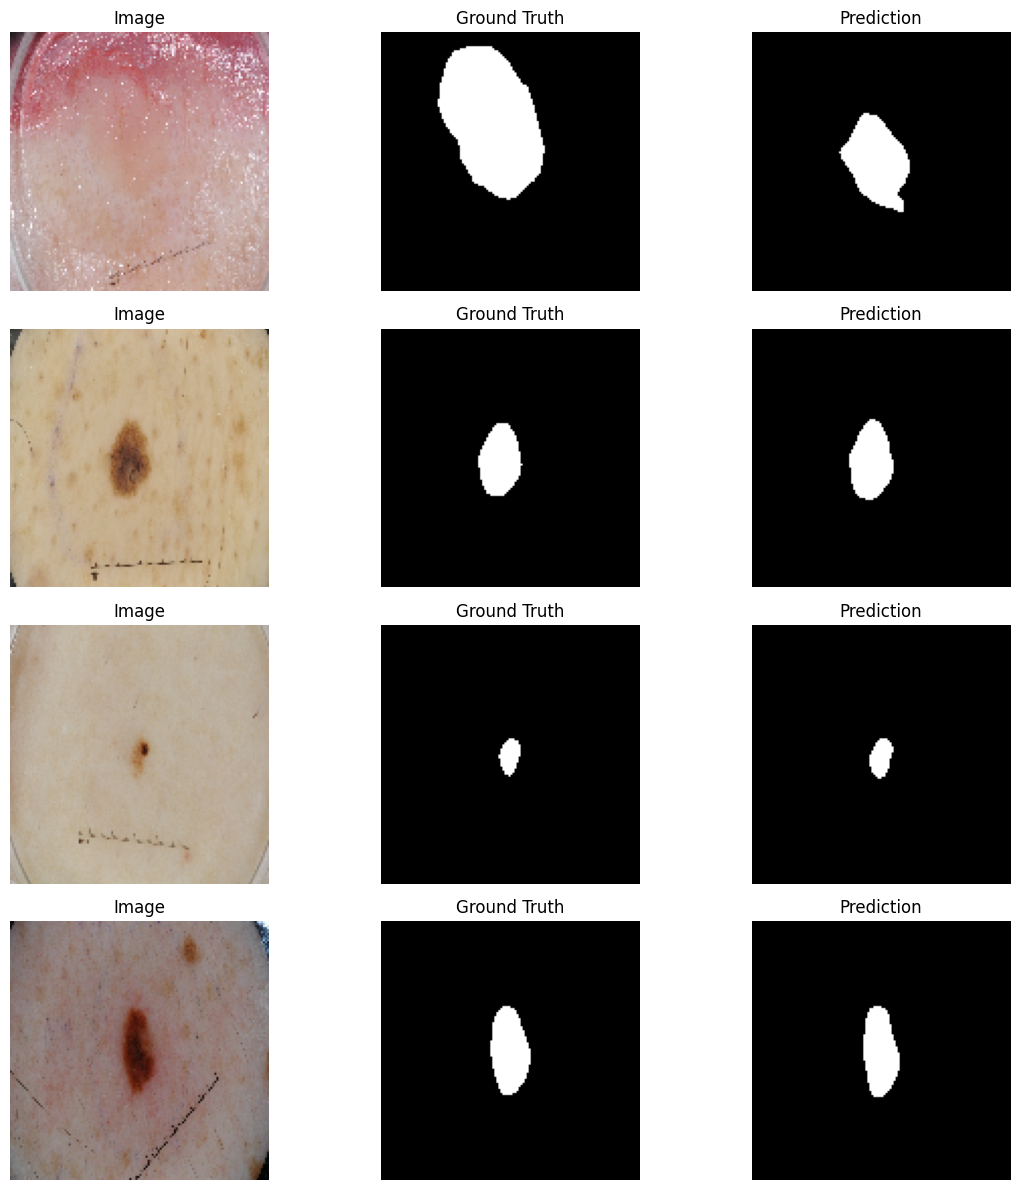

In [ ]:
plt.figure(figsize=(12, 12))

for images, masks in test_ds.take(1):

    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(np.float32)

    for i in range(4):

        plt.subplot(4, 3, 3*i + 1)
        plt.imshow(images[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(4, 3, 3*i + 2)
        plt.imshow(tf.squeeze(masks[i]), cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(4, 3, 3*i + 3)
        plt.imshow(preds[i].squeeze(), cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

plt.tight_layout()
plt.show()